Using device: cuda
✅ Part A: /kaggle/input/datasets/sethu2954/isic2019-fl-part-a
Classes: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Train:18605 | Test:4652
Client sizes: [5304, 11772, 1529]
Found 25331 images.
Pre-loading TRAIN images...


100%|██████████| 18605/18605 [08:20<00:00, 37.19it/s]


Train pre-load complete.

MAIN TRAINING — frac=0.9, rounds=20

RUNNING FEDPROX
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


  Round 1/20 fedprox → val F1:0.4996
  Round 2/20 fedprox → val F1:0.6155
  Round 3/20 fedprox → val F1:0.6726
  Round 4/20 fedprox → val F1:0.6752
  Round 5/20 fedprox → val F1:0.7370
  Round 6/20 fedprox → val F1:0.7245
  Round 7/20 fedprox → val F1:0.7398
  Round 8/20 fedprox → val F1:0.7587
  Round 9/20 fedprox → val F1:0.7686
  Round 10/20 fedprox → val F1:0.7718
  Round 11/20 fedprox → val F1:0.7733
  Round 12/20 fedprox → val F1:0.7890
  Round 13/20 fedprox → val F1:0.7929
  Round 14/20 fedprox → val F1:0.8001
  Round 15/20 fedprox → val F1:0.8377
  Round 16/20 fedprox → val F1:0.8106
  Round 17/20 fedprox → val F1:0.8179
  Round 18/20 fedprox → val F1:0.8069
  Round 19/20 fedprox → val F1:0.7687
  Round 20/20 fedprox → val F1:0.8180
✅ fedprox → F1=0.5728  Acc=0.7238

RUNNING DITTO
  Round 1/20 ditto → val F1:0.5327
  Round 2/20 ditto → val F1:0.5680
  Round 3/20 ditto → val F1:0.6432
  Round 4/20 ditto → val F1:0.6681
  Round 5/20 ditto → val F1:0.7040
  Round 6/20 ditto → val 

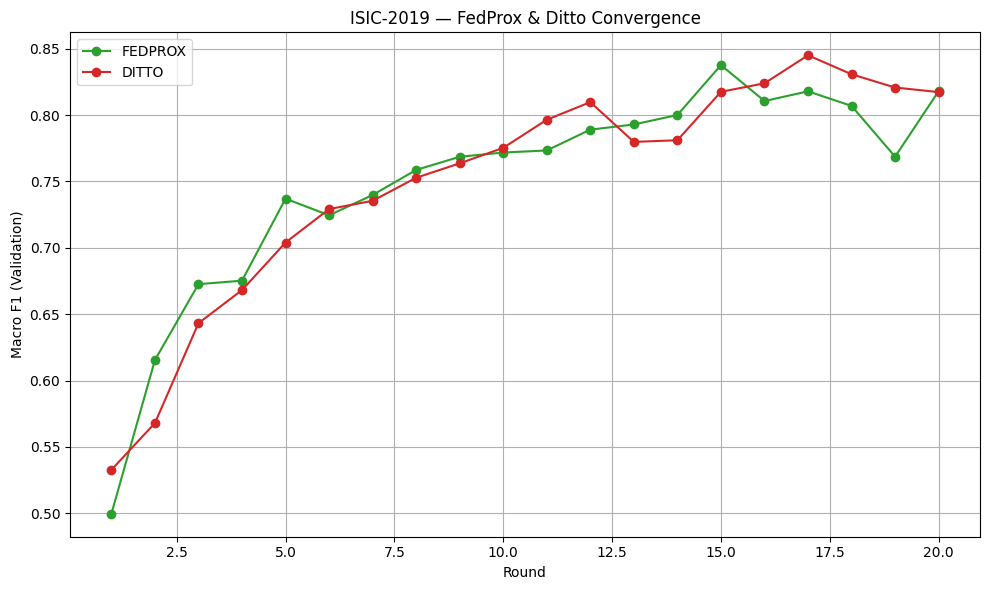


✅ Notebook 1B complete.
➡ Save output as 'isic2019-fl-part-b'
➡ Notebook 2 needs only 'isic2019-fl-part-b' as input
   (Part B already contains all Part A files)


In [1]:
# ==========================================
# NOTEBOOK 1B: ISIC-2019 FL TRAINING
# Methods: FedProx + Ditto
# Requires: isic2019-fl-part-a as input
# ==========================================

!pip install -q scikit-learn torchmetrics tqdm

import os, copy, json, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. PATHS
# ==========================================
PART_A   = "/kaggle/input/datasets/sethu2954/isic2019-fl-part-a"
DATA_DIR = "/kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification"

assert os.path.exists(os.path.join(PART_A,"meta.json")), \
    "meta.json not found in Part A"
print(f"✅ Part A: {PART_A}")

with open(os.path.join(PART_A,"meta.json")) as f:
    meta = json.load(f)

class_to_idx                = meta['class_to_idx']
class_names                 = meta['class_names']
majority_classes_per_client = meta['majority_classes_per_client']
client_sizes                = meta['client_sizes']
CHECKPOINT_ROUNDS           = meta['checkpoint_rounds']
num_classes                 = len(class_names)
MAIN_FRAC                   = 0.9

print(f"Classes: {class_names}")

# ==========================================
# 2. RELOAD DATA FROM PART A
# ==========================================
train_df   = pd.read_csv(os.path.join(PART_A,"train_df.csv"))
test_df    = pd.read_csv(os.path.join(PART_A,"test_df.csv"))
client_dfs = [pd.read_csv(os.path.join(PART_A,
              f"client_{i}_train.csv")) for i in range(3)]

print(f"Train:{len(train_df)} | Test:{len(test_df)}")
print(f"Client sizes: {[len(c) for c in client_dfs]}")

# ==========================================
# 3. IMAGE LOADING + TRANSFORMS
# ==========================================
image_paths = {}
for cn in ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']:
    cd=os.path.join(DATA_DIR,cn)
    if not os.path.isdir(cd): continue
    for fname in os.listdir(cd):
        if fname.endswith('.jpg'):
            base=fname.replace('_downsampled.jpg','').replace('.jpg','')
            image_paths[base]=os.path.join(cd,fname)
print(f"Found {len(image_paths)} images.")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

print("Pre-loading TRAIN images...")
train_tensors,train_labels=[],[]
for _,row in tqdm(train_df.iterrows(),total=len(train_df)):
    try:
        img=Image.open(
            image_paths[row['image_base']]).convert("RGB")
        train_tensors.append(transform(img))
    except Exception:
        train_tensors.append(torch.zeros(3,224,224))
    train_labels.append(row['label'])
print("Train pre-load complete.")

class StreamingDataset(Dataset):
    def __init__(self,df,image_paths,transform=None):
        self.df=df.reset_index(drop=True)
        self.image_paths=image_paths; self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        try: img=Image.open(
            self.image_paths[row['image_base']]).convert("RGB")
        except: img=Image.new("RGB",(224,224))
        if self.transform: img=self.transform(img)
        return img,int(row['label'])

test_dataset = StreamingDataset(test_df,image_paths,transform)
test_loader  = DataLoader(test_dataset,batch_size=16,shuffle=False,
                          num_workers=4,pin_memory=True)

class InMemoryDataset(Dataset):
    def __init__(self,images,labels,noise=0.0):
        self.images=images; self.labels=labels; self.noise=noise
    def __len__(self): return len(self.labels)
    def __getitem__(self,idx):
        img=self.images[idx].clone()
        if self.noise>0:
            img+=torch.randn_like(img)*self.noise/255.0
            img=torch.clamp(img,0,1)
        return img,self.labels[idx]

val_idx    = np.random.RandomState(42).choice(
                 len(train_tensors),
                 int(0.2*len(train_tensors)),replace=False)
val_loader = DataLoader(
    InMemoryDataset([train_tensors[i] for i in val_idx],
                    [train_labels[i]  for i in val_idx]),
    batch_size=16,shuffle=False,num_workers=2,pin_memory=True)

# ==========================================
# 4. DISJOINT SPLIT (same as Part A)
# ==========================================
def disjoint_non_iid_split(labels,majority_per_client,
                            majority_frac=0.9,seed=42):
    np.random.seed(seed)
    labels_arr=np.array(labels)
    n_clients=len(majority_per_client)
    assigned=np.full(len(labels),-1,dtype=int)
    for class_id in range(num_classes):
        pos=np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner=next(
            (c for c,g in enumerate(majority_per_client)
             if class_id in g),0)
        n_maj=int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    return [np.where(assigned==c)[0].tolist()
            for c in range(n_clients)]

client_indices = disjoint_non_iid_split(
    train_labels,majority_classes_per_client,
    majority_frac=MAIN_FRAC)

NOISE_LEVELS = [0.0,20.0,10.0]
class_counts    = np.bincount(train_labels,minlength=num_classes)
class_weights_t = torch.tensor(
    1.0/class_counts/(1.0/class_counts).sum(),
    dtype=torch.float32).to(device)

def get_dataloader(indices,noise=0.0,batch_size=16):
    imgs  =[train_tensors[i] for i in indices]
    lbls  =[train_labels[i]  for i in indices]
    ds    =InMemoryDataset(imgs,lbls,noise)
    counts=np.bincount(lbls,minlength=num_classes)
    sw    =1.0/counts[lbls]; sw/=sw.sum()
    samp  =WeightedRandomSampler(sw,len(sw),replacement=True)
    return DataLoader(ds,batch_size=batch_size,sampler=samp,
                      num_workers=2,pin_memory=True)

dataloaders=[get_dataloader(client_indices[i],noise=NOISE_LEVELS[i])
             for i in range(3)]

# ==========================================
# 5. MODEL
# ==========================================
def get_model():
    m=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc=nn.Linear(m.fc.in_features,num_classes)
    return m.to(device)

# ==========================================
# 6. METRICS
# ==========================================
def compute_ece(y_prob,y_true,n_bins=15):
    try:
        from torchmetrics import CalibrationError
        c=CalibrationError(task='multiclass',num_classes=num_classes,
                           n_bins=n_bins,norm='l1')
        return c(torch.tensor(y_prob),torch.tensor(y_true)).item()
    except Exception:
        pt=torch.tensor(y_prob); lt=torch.tensor(y_true)
        conf,pred=pt.max(dim=1); acc=pred.eq(lt)
        edges=torch.linspace(0,1,n_bins+1); ece=0.0
        for i in range(n_bins):
            mask=(conf>edges[i])&(conf<=edges[i+1])
            if mask.sum()>0:
                ece+=mask.sum().item()*abs(
                    acc[mask].float().mean().item()-
                    conf[mask].mean().item())
        return ece/max(len(y_true),1)

def evaluate_model(model,dataloader,return_probs=False):
    model.eval()
    all_preds,all_labels,all_probs=[],[],[]
    with torch.no_grad():
        for x,y in dataloader:
            x=x.to(device)
            probs=F.softmax(model(x),dim=1)
            preds=torch.argmax(probs,dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())
    y_true=np.array(all_labels); y_pred=np.array(all_preds)
    pc_acc,pc_rec=[],[]
    for c in range(num_classes):
        idx=y_true==c
        pc_acc.append(float(np.mean(y_pred[idx]==c))
                      if idx.sum()>0 else 0.0)
        tp=np.sum((y_pred==c)&(y_true==c))
        fn=np.sum((y_pred!=c)&(y_true==c))
        pc_rec.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return {
        'accuracy':           float(accuracy_score(y_true,y_pred)),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true,y_pred)),
        'f1_macro':           float(f1_score(y_true,y_pred,
                                   average='macro',zero_division=0)),
        'f1_per_class':       f1_score(y_true,y_pred,
                                   average=None,zero_division=0).tolist(),
        'f1_weighted':        float(f1_score(y_true,y_pred,
                                   average='weighted',zero_division=0)),
        'precision_macro':    float(precision_score(y_true,y_pred,
                                   average='macro',zero_division=0)),
        'recall_macro':       float(recall_score(y_true,y_pred,
                                   average='macro',zero_division=0)),
        'per_class_accuracy': pc_acc,
        'g_mean':             float(np.exp(np.mean(
                                   np.log([r+1e-8 for r in pc_rec])))),
        'y_true':             y_true.tolist(),
        'y_pred':             y_pred.tolist(),
        'ece':                compute_ece(all_probs,y_true.tolist())
                              if return_probs else None,
    }

# ==========================================
# 7. LOCAL TRAINING + AGGREGATION
# ==========================================
MU=0.001

def train_local(model,loader,gw,
                local_epochs=3,lr=1e-4,
                mu=0.0,ditto_lambda=0.0):
    model.train()
    opt =optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-5)
    crit=nn.CrossEntropyLoss(weight=class_weights_t)
    for _ in range(local_epochs):
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); loss=crit(model(x),y)
            if mu>0:
                loss+=(mu/2)*sum(
                    torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            if ditto_lambda>0:
                loss+=ditto_lambda*sum(
                    torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

def fedavg_agg(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

def fedprox_agg(lw,gw,mu=MU):
    avg=fedavg_agg(lw)
    for k in avg:
        if avg[k].dtype.is_floating_point:
            avg[k]=avg[k]-mu*(avg[k]-gw[k].cpu())
    return avg

# ==========================================
# 8. FL RUNNER
# ==========================================
def run_fl(name,dataloaders,client_sizes,
           rounds=20,local_epochs=3,lr=1e-4,
           save_clients=True,
           checkpoint_rounds=CHECKPOINT_ROUNDS):
    gm =get_model()
    gw ={k:v.cpu() for k,v in gm.state_dict().items()}
    cms=[get_model() for _ in range(3)]
    pw =[{k:v.cpu().clone()
          for k,v in gm.state_dict().items()} for _ in range(3)]
    best_f1,best_gw=-1.0,None
    history=[]

    for rnd in range(rounds):
        if name=='ditto':
            gl=[]
            for cid,loader in enumerate(dataloaders):
                tmp=get_model(); tmp.load_state_dict(gw,strict=True)
                gl.append(train_local(tmp,loader,gw,
                                      local_epochs=local_epochs,lr=lr))
            gw=fedavg_agg(gl); gm.load_state_dict(gw,strict=True)
            for cid,loader in enumerate(dataloaders):
                cms[cid].load_state_dict(pw[cid],strict=True)
                pw[cid]=train_local(cms[cid],loader,gw,
                                    local_epochs=local_epochs,lr=lr,
                                    ditto_lambda=0.005)
        elif name=='fedprox':
            lw=[]
            for cid,loader in enumerate(dataloaders):
                cms[cid].load_state_dict(gw,strict=True)
                lw.append(train_local(cms[cid],loader,gw,
                                      local_epochs=local_epochs,
                                      lr=lr,mu=MU))
            gw=fedprox_agg(lw,gw)
            gm.load_state_dict(gw,strict=True)

        val_m=evaluate_model(gm,val_loader)
        history.append({
            'round':rnd,'aggregation':name,
            'f1_macro':val_m['f1_macro'],
            'accuracy':val_m['accuracy'],
            'balanced_acc':val_m['balanced_accuracy'],
            'g_mean':val_m['g_mean'],
        })
        print(f"  Round {rnd+1}/{rounds} {name} → "
              f"val F1:{val_m['f1_macro']:.4f}")

        if val_m['f1_macro']>best_f1:
            best_f1=val_m['f1_macro']
            best_gw=copy.deepcopy(gw)

        if (rnd+1) in checkpoint_rounds:
            ckpt=get_model()
            ckpt.load_state_dict(gw,strict=True)
            torch.save(ckpt.state_dict(),
                       f"/kaggle/working/ckpt_{name}_round{rnd+1}.pth")

    gm.load_state_dict(best_gw,strict=True)
    if save_clients:
        for cid in range(3):
            sm=get_model()
            sm.load_state_dict(
                pw[cid] if name=='ditto'
                else cms[cid].state_dict(),strict=True)
            torch.save(sm.state_dict(),
                       f"/kaggle/working/client_{name}_{cid}.pth")
    fm=evaluate_model(gm,test_loader,return_probs=True)
    return history,gm,cms,fm

# ==========================================
# 9. MAIN RUN — FedProx + Ditto
# ==========================================
ROUNDS=20; LOCAL_EPOCHS=3; LR=1e-4
METHODS=['fedprox','ditto']

print(f"\n{'='*60}")
print(f"MAIN TRAINING — frac={MAIN_FRAC}, rounds={ROUNDS}")
print(f"{'='*60}")

all_history={}; final_models={}; final_metrics={}

for name in METHODS:
    print(f"\n{'='*50}\nRUNNING {name.upper()}\n{'='*50}")
    hist,gm,cms,fm=run_fl(
        name,dataloaders,client_sizes,
        rounds=ROUNDS,local_epochs=LOCAL_EPOCHS,lr=LR,
        save_clients=True,checkpoint_rounds=CHECKPOINT_ROUNDS)
    all_history[name]=hist
    final_models[name]=gm; final_metrics[name]=fm
    torch.save(gm.state_dict(),
               f"/kaggle/working/final_model_{name}.pth")
    print(f"✅ {name} → F1={fm['f1_macro']:.4f}  "
          f"Acc={fm['accuracy']:.4f}")

# ==========================================
# 10. ABLATION — FedProx + Ditto
# ==========================================
ABLATION_ROUNDS=10; ABLATION_FRACS=[0.5,0.7]

print(f"\n{'='*60}\nABLATION\n{'='*60}")
ablation_results=[]
for name in METHODS:
    m=final_metrics[name]
    ablation_results.append({
        'majority_frac':MAIN_FRAC,'method':name,
        'f1_macro':m['f1_macro'],'accuracy':m['accuracy'],
        'g_mean':m['g_mean'],'balanced_acc':m['balanced_accuracy'],
    })

for frac in ABLATION_FRACS:
    print(f"\n--- frac={frac} ---")
    abl_idx=disjoint_non_iid_split(
        train_labels,majority_classes_per_client,majority_frac=frac)
    abl_sz =[len(i) for i in abl_idx]
    abl_dl =[get_dataloader(abl_idx[i],noise=NOISE_LEVELS[i])
             for i in range(3)]
    for name in METHODS:
        _,gm,_,fm=run_fl(name,abl_dl,abl_sz,
                          rounds=ABLATION_ROUNDS,
                          local_epochs=LOCAL_EPOCHS,lr=LR,
                          save_clients=False,checkpoint_rounds=[])
        ablation_results.append({
            'majority_frac':frac,'method':name,
            'f1_macro':fm['f1_macro'],'accuracy':fm['accuracy'],
            'g_mean':fm['g_mean'],'balanced_acc':fm['balanced_accuracy'],
        })
        print(f"  ✅ {name} frac={frac} → F1={fm['f1_macro']:.4f}")

# ==========================================
# 11. SAVE + COPY PART A FILES FORWARD
# ==========================================
hist_flat=[]
for name,hist in all_history.items():
    for rec in hist: hist_flat.append(rec)
pd.DataFrame(hist_flat).to_csv(
    "/kaggle/working/fl_results_part_b.csv",index=False)
pd.DataFrame(ablation_results).to_csv(
    "/kaggle/working/ablation_part_b.csv",index=False)

# Copy all Part A files forward
files_a=[
    "test_df.csv","train_df.csv","meta.json",
    "fl_results_part_a.csv","ablation_part_a.csv",
    "client_0_train.csv","client_1_train.csv","client_2_train.csv",
    "client_0_test_split.csv","client_1_test_split.csv",
    "client_2_test_split.csv",
    "final_model_fedavg.pth","final_model_weighted_fedavg.pth",
    "client_fedavg_0.pth","client_fedavg_1.pth","client_fedavg_2.pth",
    "client_weighted_fedavg_0.pth","client_weighted_fedavg_1.pth",
    "client_weighted_fedavg_2.pth",
]
for fname in files_a:
    src=os.path.join(PART_A,fname)
    if os.path.exists(src):
        shutil.copy(src,f"/kaggle/working/{fname}")
        print(f"  ✅ copied {fname}")

# Copy Part A checkpoints
for name in ['fedavg','weighted_fedavg']:
    for rnd in CHECKPOINT_ROUNDS:
        fname=f"ckpt_{name}_round{rnd}.pth"
        src=os.path.join(PART_A,fname)
        if os.path.exists(src):
            shutil.copy(src,f"/kaggle/working/{fname}")

# Merge all round history
hist_a=pd.read_csv("/kaggle/working/fl_results_part_a.csv")
hist_b=pd.DataFrame(hist_flat)
pd.concat([hist_a,hist_b],ignore_index=True).to_csv(
    "/kaggle/working/fl_results_all_methods.csv",index=False)

# Merge ablations
abl_a=pd.read_csv("/kaggle/working/ablation_part_a.csv")
abl_b=pd.DataFrame(ablation_results)
pd.concat([abl_a,abl_b],ignore_index=True).to_csv(
    "/kaggle/working/ablation_results.csv",index=False)

# Convergence plot Part B
df_h=pd.DataFrame(hist_flat)
plt.figure(figsize=(10,6))
colors={'fedprox':'#2ca02c','ditto':'#d62728'}
for name in METHODS:
    sub=df_h[df_h['aggregation']==name]
    plt.plot(sub['round']+1,sub['f1_macro'],
             marker='o',color=colors[name],label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('ISIC-2019 — FedProx & Ditto Convergence')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_part_b.png",dpi=150)
plt.show()

print("\n✅ Notebook 1B complete.")
print("➡ Save output as 'isic2019-fl-part-b'")
print("➡ Notebook 2 needs only 'isic2019-fl-part-b' as input")
print("   (Part B already contains all Part A files)")